# LIB

In [1]:
import argparse
import os
import time
import datetime
import torch
import torch.optim as optim
from math import ceil
from torch.utils.data import DataLoader
from dataset.dataset import CityScapesDataset
from utils.metric import runningScore, averageMeter
import numpy as np
from tqdm import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import random
import matplotlib.pyplot as plt # 引入繪圖庫
from copy import deepcopy

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
torch.cuda.is_available()

True

# parameters

In [3]:
# n_train=2436
n_train=2476
n_val=400


batchsize   = 48
Epoch       = 250
img_size    = [256, 512]
model_name  = 'model_task2'
task        = 'cat'
lr = 2e-3

final_save_path='./'+model_name+'.pth'

# Train

In [4]:
def train(epoch, data_loader, Net, optimizer,
          criterion_main, criterion_aux, Meter,
          total_epochs=100, aux_weight=0.4):
    """
    訓練一個 epoch（支援 Deep Supervision）

    Args:
        epoch: 當前 epoch 編號 (從 0 開始)
        data_loader: 訓練 dataloader
        Net: 模型 (train 模式下可能回傳 logits 或 (main, aux))
        optimizer: 優化器
        criterion_main: 主 head 用的 loss（這裡用 FinalCombinedLoss）
        criterion_aux: aux head 用的 loss（這裡用 CrossEntropyLoss）
        Meter: 指標記錄器 dict，至少包含 'metric' 和 'loss'
        total_epochs: 總共訓練幾個 epoch，只是用來顯示在 tqdm 上
        aux_weight: deep supervision 的 aux loss 權重

    Returns:
        mIoU, loss_avg
    """
    Net.train()
    timeStart = time.time()

    # reset meter
    for _, v in Meter.items():
        v.reset()

    n_samples = len(data_loader.dataset)

    with tqdm(total=n_samples,
              desc=f'Epoch {epoch + 1}/{total_epochs}',
              unit='img') as pbar:
        for i, (data, target) in enumerate(data_loader):
            data   = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            # ---- forward ----
            outputs = Net(data)

            # Net.train() 下，MobileLiteUNet 會回傳 (main_logits, aux_logits)
            if isinstance(outputs, (tuple, list)):
                main_pred, aux_pred = outputs
            else:
                main_pred, aux_pred = outputs, None

            # ---- 主 head loss ----
            loss_main = criterion_main(main_pred, target)

            # ---- aux head loss（有 aux_pred 才算）----
            if aux_pred is not None and criterion_aux is not None:
                loss_aux = criterion_aux(aux_pred, target)
                loss = loss_main + aux_weight * loss_aux
            else:
                loss = loss_main

            # ---- backward & update ----
            loss.backward()
            torch.nn.utils.clip_grad_norm_(Net.parameters(), max_norm=1.0)
            optimizer.step()

            training_loss = loss.item()
            pbar.set_postfix(loss=f'{training_loss:.4f}')

            # ---- 更新 metrics（只用 main_pred）----
            pred_labels = main_pred.data.max(1)[1]  # -> (B, H, W)

            Meter['metric'].update(
                target.data.cpu().numpy(),
                pred_labels.data.cpu().numpy()
            )
            Meter['loss'].update(training_loss, data.size(0))

            pbar.update(data.shape[0])

    timeEnd = time.time()
    score, class_iou = Meter['metric'].get_scores()
    loss_avg = Meter['loss'].avg

    print('\n[Training Summary]')
    print(
        f'  Loss: {loss_avg:.4f} | '
        f'Overall Acc: {score["OverallAcc"]:.4f} | '
        f'Mean Acc: {score["MeanAcc"]:.4f} | '
        f'mIoU: {score["mIoU"]:.4f} | '
        f'Time: {timeEnd - timeStart:.1f}s'
    )

    return score['mIoU'], loss_avg


# Val

In [5]:
def val(epoch, data_loader, Net, criterion, Meter, total_epochs=100):
    """
    驗證一個 epoch（只使用 main logits，不用 aux head）
    
    Args:
        epoch: 當前 epoch 編號
        data_loader: 驗證數據加載器
        Net: 模型
        criterion: 驗證用的損失函數（建議用 FinalCombinedLoss）
        Meter: 指標記錄器 dict
        total_epochs: 總 epoch 數
    
    Returns:
        mIoU: 返回本 epoch 的 mIoU
    """
    Net.eval()
    timeStart = time.time()
    
    # reset meter
    for _, v in Meter.items():
        v.reset()
    
    n_samples = len(data_loader.dataset)
    
    with torch.no_grad():
        with tqdm(total=n_samples,
                  desc=f'Validation {epoch + 1}/{total_epochs}',
                  unit='img') as pbar:
            for i, (data, target) in enumerate(data_loader):
                data   = data.to(device)
                target = target.to(device)
                
                outputs = Net(data)

                # eval 模式下 MobileLiteUNet 只會回傳 logits
                if isinstance(outputs, (tuple, list)):
                    pred = outputs[0]
                else:
                    pred = outputs
                
                loss = criterion(pred, target)
                val_loss = loss.item()
                pbar.set_postfix(loss=f'{val_loss:.4f}')
                
                pred_labels = pred.data.max(1)[1]
                Meter['metric'].update(
                    target.data.cpu().numpy(),
                    pred_labels.data.cpu().numpy()
                )
                Meter['loss'].update(val_loss, data.size(0))
                
                pbar.update(data.shape[0])
    
    timeEnd = time.time()
    score, class_iou = Meter['metric'].get_scores()
    loss_avg = Meter['loss'].avg
    
    print('\n[Validation Summary]')
    print(
        f'  Loss: {loss_avg:.4f} | '
        f'Overall Acc: {score["OverallAcc"]:.4f} | '
        f'Mean Acc: {score["MeanAcc"]:.4f} | '
        f'mIoU: {score["mIoU"]:.4f} | '
        f'Time: {timeEnd-timeStart:.1f}s'
    )
    
    return score['mIoU']


best_val_miou=0
current_val_miou=0

# Augmentation

In [6]:
# -*- coding: utf-8 -*-
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
import random

# 如果你的 ignore label 不是 255，在這裡改
IGNORE_INDEX = 255


# ----------------- 小工具函式們 -----------------

def random_crop_resize(img, label, out_h, out_w, min_scale=0.5, p=0.4):
    """
    隨機裁一塊再 resize 回原尺寸，增加構圖變化。
    """
    if random.random() > p:
        return img, label

    h, w = img.shape[:2]
    th = max(1, int(h * min_scale))
    tw = max(1, int(w * min_scale))

    if th == h and tw == w:
        return img, label

    y1 = random.randint(0, h - th)
    x1 = random.randint(0, w - tw)

    img = img[y1:y1 + th, x1:x1 + tw]
    label = label[y1:y1 + th, x1:x1 + tw]

    img_pil = Image.fromarray(img)
    label_pil = Image.fromarray(label)

    img = np.array(img_pil.resize((out_w, out_h), Image.BILINEAR))
    label = np.array(label_pil.resize((out_w, out_h), Image.NEAREST))

    return img, label


def random_affine(img, label, max_shear=0.1, max_rotate=10, p=0.3):
    """
    小幅度的 shear + rotate（保持 label 對齊）
    """
    if random.random() > p:
        return img, label

    h, w = img.shape[:2]
    img_pil = Image.fromarray(img)
    label_pil = Image.fromarray(label)

    angle = random.uniform(-max_rotate, max_rotate)
    shear = random.uniform(-max_shear, max_shear)

    img_pil = img_pil.transform(
        (w, h),
        Image.AFFINE,
        (1, shear, 0, shear, 1, 0),
        resample=Image.BILINEAR,
    ).rotate(angle, resample=Image.BILINEAR, fillcolor=0)

    label_pil = label_pil.transform(
        (w, h),
        Image.AFFINE,
        (1, shear, 0, shear, 1, 0),
        resample=Image.NEAREST,
    ).rotate(angle, resample=Image.NEAREST, fillcolor=IGNORE_INDEX)

    return np.array(img_pil), np.array(label_pil)


def random_gamma(img, gamma_range=(0.7, 1.5), p=0.4):
    """
    Gamma 校正，模擬曝光/光線變化。
    """
    if random.random() > p:
        return img
    gamma = random.uniform(*gamma_range)
    img_f = img.astype(np.float32) / 255.0
    img_f = img_f ** gamma
    img_f = np.clip(img_f * 255.0, 0, 255).astype(np.uint8)
    return img_f


def random_gray(img, p=0.1):
    """
    少量樣本轉灰階，讓模型更不依賴顏色。
    """
    if random.random() > p:
        return img
    gray = img.mean(axis=2, keepdims=True)
    return np.repeat(gray.astype(np.uint8), 3, axis=2)


def random_salt_pepper(img, p=0.2, amount=0.005):
    """
    salt-and-pepper noise，模擬 sensor 雜訊 / 壓縮 artifact。
    """
    if random.random() > p:
        return img
    h, w, c = img.shape
    num = int(h * w * amount)
    if num <= 0:
        return img
    ys = np.random.randint(0, h, num)
    xs = np.random.randint(0, w, num)
    img_sp = img.copy()
    img_sp[ys, xs] = np.random.choice([0, 255], size=(num, c))
    return img_sp


def random_cutout(img, label, max_ratio=0.4, p=0.4, ignore_index=IGNORE_INDEX):
    """
    Cutout：遮一塊區域，並把那塊 label 設成 ignore_index。
    """
    if random.random() > p:
        return img, label

    h, w = img.shape[:2]
    cut_h = int(h * random.uniform(0.1, max_ratio))
    cut_w = int(w * random.uniform(0.1, max_ratio))

    if cut_h <= 0 or cut_w <= 0:
        return img, label

    y1 = random.randint(0, h - cut_h)
    x1 = random.randint(0, w - cut_w)

    img = img.copy()
    label = label.copy()

    # 這裡你可以換成 random noise/block
    img[y1:y1 + cut_h, x1:x1 + cut_w, :] = 0
    label[y1:y1 + cut_h, x1:x1 + cut_w] = ignore_index

    return img, label


# ----------------- 強版 early augmentation -----------------

def early_augmentation(img, label):
    """前期強增強（幾何變化 + 顏色/雜訊 + Cutout）"""
    img = img.astype(np.uint8)
    h, w = img.shape[:2]

    # 1) Random crop + resize 回原尺寸（構圖變化）
    img, label = random_crop_resize(img, label, h, w, min_scale=0.5, p=0.4)

    # 2) Random Scale（原本的邏輯，稍微調概率）
    if random.random() < 0.6:
        scale = random.uniform(0.6, 1.4)
        h, w = img.shape[:2]
        new_w, new_h = int(w * scale), int(h * scale)

        img_pil = Image.fromarray(img)
        label_pil = Image.fromarray(label)

        img_pil = img_pil.resize((new_w, new_h), Image.BILINEAR)
        label_pil = label_pil.resize((new_w, new_h), Image.NEAREST)

        img = np.array(img_pil)
        label = np.array(label_pil)

        if scale > 1.0:
            # random crop 回原尺寸
            start_h = random.randint(0, new_h - h)
            start_w = random.randint(0, new_w - w)
            img = img[start_h:start_h + h, start_w:start_w + w]
            label = label[start_h:start_h + h, start_w:start_w + w]
        else:
            # 中心 padding
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2
            img_padded = np.zeros((h, w, 3), dtype=np.uint8)
            label_padded = np.ones((h, w), dtype=label.dtype) * IGNORE_INDEX
            img_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = img
            label_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = label
            img = img_padded
            label = label_padded

    # 3) Random Flip
    if random.random() < 0.5:
        img = img[:, ::-1, :].copy()
        label = label[:, ::-1].copy()

    # 4) Random Affine (shear + 小旋轉)
    img, label = random_affine(img, label, max_shear=0.1, max_rotate=10, p=0.3)

    # 5) Color Jitter + Gamma + 灰階
    img_pil = Image.fromarray(img)
    if random.random() < 0.6:
        factor = random.uniform(0.6, 1.4)
        img_pil = ImageEnhance.Brightness(img_pil).enhance(factor)
    if random.random() < 0.6:
        factor = random.uniform(0.6, 1.4)
        img_pil = ImageEnhance.Contrast(img_pil).enhance(factor)
    img = np.array(img_pil)

    img = random_gamma(img, gamma_range=(0.7, 1.5), p=0.4)
    img = random_gray(img, p=0.1)

    # 6) Random Blur
    if random.random() < 0.3:
        img_pil = Image.fromarray(img)
        img_pil = img_pil.filter(
            ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0))
        )
        img = np.array(img_pil)

    # 7) Noise（Gaussian + Salt-Pepper）
    if random.random() < 0.4:
        noise = np.random.normal(0, random.uniform(5, 15), img.shape)
        img = img.astype(np.float32) + noise
        img = np.clip(img, 0, 255).astype(np.uint8)

    img = random_salt_pepper(img, p=0.2, amount=0.005)

    # 8) Cutout（遮住一塊 + ignore label）
    img, label = random_cutout(img, label, max_ratio=0.4, p=0.4, ignore_index=IGNORE_INDEX)

    return img, label


# ----------------- 後期輕增強 -----------------

def late_augmentation(img, label):
    """後期輕增強：幾何變化減少，只做小幅度 jitter。"""
    img = img.astype(np.uint8)
    h, w = img.shape[:2]

    # 小範圍 scale
    if random.random() < 0.5:
        scale = random.uniform(0.8, 1.2)
        new_w, new_h = int(w * scale), int(h * scale)

        img_pil = Image.fromarray(img)
        label_pil = Image.fromarray(label)
        img_pil = img_pil.resize((new_w, new_h), Image.BILINEAR)
        label_pil = label_pil.resize((new_w, new_h), Image.NEAREST)
        img = np.array(img_pil)
        label = np.array(label_pil)

        if scale > 1.0:
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            img = img[start_h:start_h + h, start_w:start_w + w]
            label = label[start_h:start_h + h, start_w:start_w + w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2
            img_padded = np.zeros((h, w, 3), dtype=np.uint8)
            label_padded = np.ones((h, w), dtype=label.dtype) * IGNORE_INDEX
            img_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = img
            label_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = label
            img = img_padded
            label = label_padded

    # Flip
    if random.random() < 0.5:
        img = img[:, ::-1, :].copy()
        label = label[:, ::-1].copy()

    # 輕微 brightness + gamma
    img_pil = Image.fromarray(img)
    if random.random() < 0.4:
        factor = random.uniform(0.8, 1.2)
        img_pil = ImageEnhance.Brightness(img_pil).enhance(factor)
    img = np.array(img_pil)

    img = random_gamma(img, gamma_range=(0.9, 1.1), p=0.3)

    return img, label


# ----------------- 標準版（不分 early/late 時用） -----------------

def enhanced_augmentation(img, label):
    """標準增強（中等強度）"""
    img = img.astype(np.uint8)
    h, w = img.shape[:2]

    # 中等 scale 範圍
    if random.random() < 0.6:
        scale = random.uniform(0.7, 1.3)
        new_w, new_h = int(w * scale), int(h * scale)

        img_pil = Image.fromarray(img)
        label_pil = Image.fromarray(label)
        img_pil = img_pil.resize((new_w, new_h), Image.BILINEAR)
        label_pil = label_pil.resize((new_w, new_h), Image.NEAREST)
        img = np.array(img_pil)
        label = np.array(label_pil)

        if scale > 1.0:
            start_h = random.randint(0, new_h - h)
            start_w = random.randint(0, new_w - w)
            img = img[start_h:start_h + h, start_w:start_w + w]
            label = label[start_h:start_h + h, start_w:start_w + w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2
            img_padded = np.zeros((h, w, 3), dtype=np.uint8)
            label_padded = np.ones((h, w), dtype=label.dtype) * IGNORE_INDEX
            img_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = img
            label_padded[pad_h:pad_h + new_h, pad_w:pad_w + new_w] = label
            img = img_padded
            label = label_padded

    # Flip
    if random.random() < 0.5:
        img = img[:, ::-1, :].copy()
        label = label[:, ::-1].copy()

    # 顏色 jitter + gamma
    img_pil = Image.fromarray(img)
    if random.random() < 0.5:
        factor = random.uniform(0.7, 1.3)
        img_pil = ImageEnhance.Brightness(img_pil).enhance(factor)
    if random.random() < 0.5:
        factor = random.uniform(0.7, 1.3)
        img_pil = ImageEnhance.Contrast(img_pil).enhance(factor)
    img = np.array(img_pil)

    img = random_gamma(img, gamma_range=(0.8, 1.3), p=0.4)

    # 輕微 blur
    if random.random() < 0.2:
        img_pil = Image.fromarray(img)
        img_pil = img_pil.filter(
            ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5))
        )
        img = np.array(img_pil)

    return img, label


print("✓ Data augmentation functions loaded (強化版)")


✓ Data augmentation functions loaded (強化版)


# Loss Mix

In [7]:
class ImprovedOhemCELoss(nn.Module):
    """
    改進的 OHEM：保留最困難的前 k% 像素
    """
    def __init__(self, thresh=0.5, ignore_index=255):
        super(ImprovedOhemCELoss, self).__init__()
        self.thresh = thresh
        self.ignore_index = ignore_index
        self.criteria = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, logits, labels):
        # logits: (B, C, H, W)
        # labels: (B, H, W)
        loss = self.criteria(logits, labels).view(-1)  # (B*H*W,)
        # CrossEntropyLoss 對 ignore_index 會給 0，排在最後沒事

        loss, _ = torch.sort(loss, descending=True)
        
        n_keep = max(int(loss.numel() * self.thresh), 1)
        loss = loss[:n_keep]
        
        return loss.mean()


class ImprovedDiceLoss(nn.Module):
    def __init__(self, num_classes=8, ignore_index=255, smooth=1.5):
        super(ImprovedDiceLoss, self).__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits, labels):
        probs = torch.softmax(logits, dim=1)  # (B, C, H, W)
        
        labels_one_hot = torch.zeros_like(probs)
        valid_mask = (labels != self.ignore_index)

        for c in range(self.num_classes):
            labels_one_hot[:, c, :, :] = (labels == c).float() * valid_mask.float()
        
        intersection = (probs * labels_one_hot).sum(dim=(0, 2, 3))
        union = probs.sum(dim=(0, 2, 3)) + labels_one_hot.sum(dim=(0, 2, 3))
        
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean()


class FinalCombinedLoss(nn.Module):
    """
    最後一跑用的 Loss：
    OHEM CE (60%) + Dice (40%)
    """
    def __init__(self, num_classes=8, ignore_index=255):
        super(FinalCombinedLoss, self).__init__()
        self.ohem = ImprovedOhemCELoss(thresh=0.5, ignore_index=ignore_index)
        self.dice = ImprovedDiceLoss(num_classes=num_classes, ignore_index=ignore_index, smooth=1.5)

    def forward(self, logits, labels):
        ohem_loss = self.ohem(logits, labels)
        dice_loss = self.dice(logits, labels)
        return 0.6 * ohem_loss + 0.4 * dice_loss


# Scheduler

In [8]:
class BetterWarmupCosineScheduler:
    """
    改进的 Warmup + Cosine 调度：
    - 更长的 warmup
    - 更平滑的衰减
    - 去除 staged decay (减少震荡)
    """
    def __init__(self, optimizer, warmup_epochs=10, total_epochs=250, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.defaults['lr']

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Warmup: 线性增长
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Pure Cosine (无 staged decay)
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.base_lr - self.min_lr) * 0.5 * (1 + np.cos(np.pi * progress))

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

# EMA

In [9]:
class EMA:
        def __init__(self, model, decay=0.9998):
            self.model = model
            self.decay = decay
            self.shadow = {}
            self.backup = {}
            self.register()

        def register(self):
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    self.shadow[name] = param.data.clone()

        def update(self):
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    new_average = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                    self.shadow[name] = new_average.clone()

        def apply_shadow(self):
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    self.backup[name] = param.data
                    param.data = self.shadow[name]

        def restore(self):
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    param.data = self.backup[name]
            self.backup = {}

# Main

In [10]:
import network2

if __name__ == '__main__':

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   

    assert task in ['cat'], 'wrong value of task'
    if task == 'cat':
        num_classes = 8
        
    training_meter = {
        'metric': runningScore(num_classes),
        'loss':   averageMeter(),
        'time':   averageMeter()
    }
    validation_meter = {
        'metric': runningScore(num_classes),
        'loss':   averageMeter(),
        'time':   averageMeter()
    }

    print(str(datetime.datetime.now()))
    print(
        'batchsize %3d | epoch %3d | img_size  %4d %4d | task  %6s | model_name  %25s '
        % (batchsize, Epoch, img_size[0], img_size[1], task, model_name)
    )

    # ---------------- Dataset & Dataloader ----------------
    TrainingDataset = CityScapesDataset(
        "data", "training", img_size, 
        task=task, 
        augmentation=early_augmentation
    )
    ValidationDataset = CityScapesDataset(
        "data", "validation", img_size, task=task
    )

    TrainingLoader = DataLoader(
        TrainingDataset, 
        batch_size=batchsize, 
        shuffle=True, 
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
    ValidationLoader = DataLoader(
        ValidationDataset, 
        batch_size=batchsize, 
        shuffle=False, 
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    num_batch = ceil(len(TrainingDataset) / batchsize)
    n_train   = len(TrainingDataset)
    n_val     = len(ValidationDataset)
    print(f'Training samples: {n_train}')
    print(f'Validation samples: {n_val}')
    
    # ==========================================
    # 使用 MobileLiteUNet (base_c=8)
    # ==========================================
    Net = network2.MobileLiteUNet(
        n_channels=3,
        n_classes=num_classes,
        base_c=8
    )
    Net = Net.to(device)

    # EMA
    ema = EMA(Net, decay=0.998)
    
    # Optimizer
    optimizer = optim.AdamW(
        Net.parameters(),
        lr=lr,
        weight_decay=3e-5,
        betas=(0.9, 0.999)
    )
    
    # Scheduler
    scheduler = BetterWarmupCosineScheduler(
        optimizer,
        warmup_epochs=10,
        total_epochs=Epoch,
        min_lr=1e-6
    )

    # ---------- 定義主 / aux loss ----------
    ignore_index = 255

    # 主 head：用你現在的 FinalCombinedLoss（OHEM + Dice）
    criterion_main = FinalCombinedLoss(num_classes=num_classes, ignore_index=ignore_index)

    # Aux head：穩定一點，單純 CE
    criterion_aux = nn.CrossEntropyLoss(ignore_index=ignore_index)
    
    # ---------- 訓練狀態變數 ----------
    start_epoch     = 0
    best_state_dict = None
    best_val_miou   = 0.0
    best_ema_miou   = 0.0
    patience_counter = 0
    patience_limit   = 35  # early stop patience
    
    # 記錄歷史
    train_loss_history   = []
    train_miou_history   = []
    val_loss_history     = []
    val_miou_history     = []
    val_ema_miou_history = []
    lr_history           = []

    # ===========================
    #       Training Loop
    # ===========================
    for epoch in range(start_epoch, Epoch):

        # 動態切換增強策略
        if epoch == int(Epoch * 0.85):
            print(f"\n{'='*80}")
            print(f"Switching to light augmentation at epoch {epoch + 1}")
            print(f"{'='*80}\n")
            TrainingDataset.augmentation = late_augmentation
    
        # ---------- Training ----------
        for _, v in training_meter.items():
            v.reset()
    
        show_lr = optimizer.param_groups[0]['lr']
        print('learning rate is : ', show_lr)
        lr_history.append(show_lr)
    
        current_train_miou, current_train_loss = train(
            epoch,
            TrainingLoader,
            Net,
            optimizer,
            criterion_main,    # 主 head loss
            criterion_aux,     # aux head loss
            training_meter,
            total_epochs=Epoch,
            aux_weight=0.4,    # deep supervision aux 權重
        )
    
        # 更新 EMA 參數
        ema.update()
    
        # 紀錄 training history
        train_loss_history.append(current_train_loss)
        train_miou_history.append(current_train_miou)
    
        # 更新 scheduler
        scheduler.step(epoch)
    
        # ---------- Validation (原模型) ----------
        for _, v in validation_meter.items():
            v.reset()
    
        current_val_miou = val(
            epoch,
            ValidationLoader,
            Net,
            criterion_main,      # 驗證只看主 head
            validation_meter,
            total_epochs=Epoch
        )
        current_val_loss = validation_meter['loss'].avg
    
        val_miou_history.append(current_val_miou)
        val_loss_history.append(current_val_loss)
    
        # ---------- Validation (EMA 模型) ----------
        ema.apply_shadow()
        for _, v in validation_meter.items():
            v.reset()
    
        current_ema_miou = val(
            epoch,
            ValidationLoader,
            Net,
            criterion_main,
            validation_meter,
            total_epochs=Epoch
        )
        val_ema_miou_history.append(current_ema_miou)
    
        ema.restore()
    
        # ---------- 儲存最佳模型 ----------
        use_miou = max(current_val_miou, current_ema_miou)
    
        if use_miou > best_val_miou:
            best_val_miou = use_miou
    
            if current_ema_miou >= current_val_miou:
                ema.apply_shadow()
                best_state_dict = deepcopy(Net.state_dict())
                ema.restore()
                model_type    = "EMA"
                best_ema_miou = current_ema_miou
            else:
                best_state_dict = deepcopy(Net.state_dict())
                model_type = "Original"
    
            torch.save(best_state_dict, final_save_path)
            print(f"\n{'='*80}")
            print(f"✓ Best {model_type} model saved! mIoU: {best_val_miou:.4f}")
            print(f"  (val mIoU = {current_val_miou:.4f}, ema mIoU = {current_ema_miou:.4f})")
            print(f"  Saved to: {final_save_path}")
            print(f"{'='*80}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"\n  No improvement. Patience: {patience_counter}/{patience_limit}")
            print(
                f"  (val mIoU = {current_val_miou:.4f}, "
                f"ema mIoU = {current_ema_miou:.4f}, best = {best_val_miou:.4f})"
            )
    
        if patience_counter >= patience_limit:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

    print(str(datetime.datetime.now()))
    print('\n' + '=' * 80)
    print('Training completed!')
    print(f'Best validation mIoU: {best_val_miou:.4f}')
    print(f'Model saved to: {final_save_path}')
    print(str(datetime.datetime.now()))
    print('=' * 80)


2025-12-01 09:38:24.981164
batchsize  48 | epoch 250 | img_size   256  512 | task     cat | model_name                model_task2 
Training samples: 2476
Validation samples: 400
learning rate is :  0.002


Epoch 1/250: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 2476/2476 [02:39<00:00, 15.50img/s, loss=1.7135]



[Training Summary]
  Loss: 2.0897 | Overall Acc: 0.4843 | Mean Acc: 0.2987 | mIoU: 0.1742 | Time: 159.7s


Validation 1/250: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:26<00:00, 15.13img/s, loss=1.2036]



[Validation Summary]
  Loss: 1.3063 | Overall Acc: 0.6627 | Mean Acc: 0.4067 | mIoU: 0.3116 | Time: 26.4s


...


[Training Summary]
  Loss: 0.6409 | Overall Acc: 0.8819 | Mean Acc: 0.7534 | mIoU: 0.6561 | Time: 156.1s


Validation 235/250: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:26<00:00, 15.29img/s, loss=0.4273]



[Validation Summary]
  Loss: 0.5463 | Overall Acc: 0.8758 | Mean Acc: 0.7744 | mIoU: 0.6723 | Time: 26.2s


Validation 235/250: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:26<00:00, 15.28img/s, loss=1.5994]


[Validation Summary]
  Loss: 1.6116 | Overall Acc: 0.3836 | Mean Acc: 0.1250 | mIoU: 0.0480 | Time: 26.2s

  No improvement. Patience: 35/35
  (val mIoU = 0.6723, ema mIoU = 0.0480, best = 0.6739)

Early stopping triggered at epoch 235
2025-12-01 23:15:54.643715

Training completed!
Best validation mIoU: 0.6739
Model saved to: ./model_task2_test.pth
2025-12-01 23:15:54.643794


# plt


✓ Training curves saved to: training_curves_advanced.png


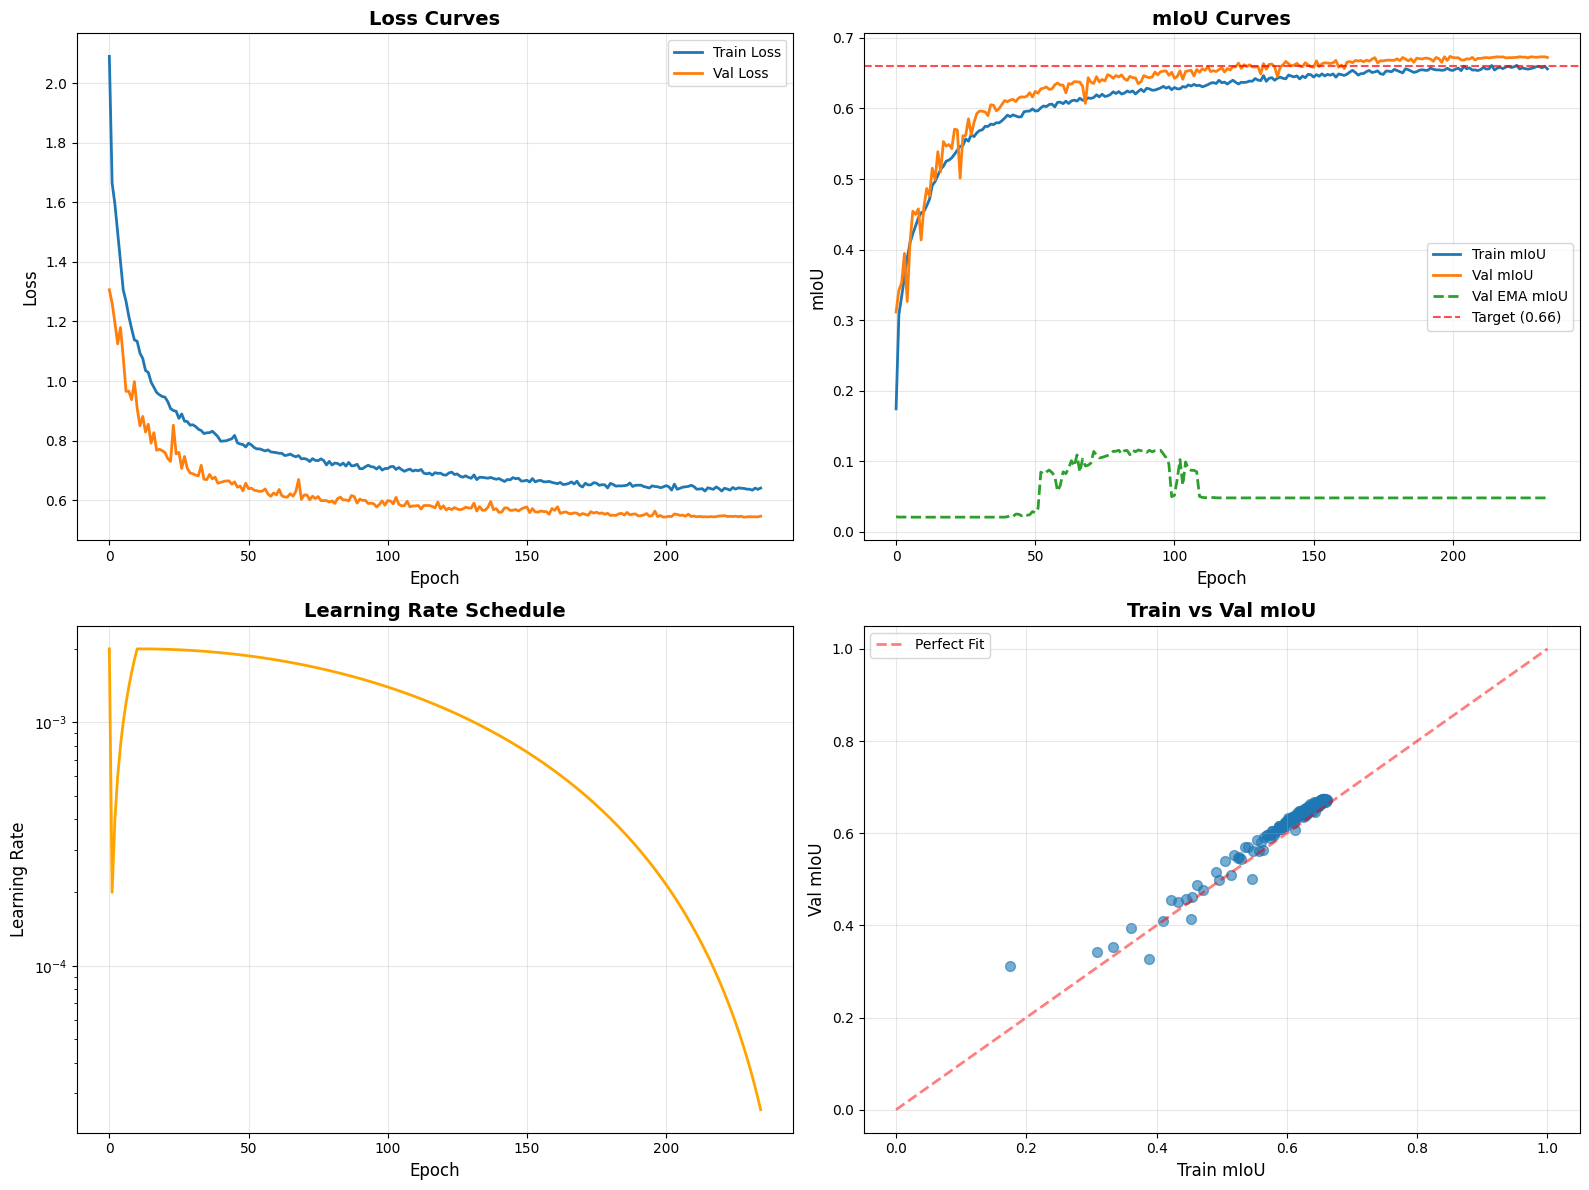

In [11]:
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Loss 曲線
    axes[0, 0].plot(train_loss_history, label='Train Loss', linewidth=2)
    axes[0, 0].plot(val_loss_history, label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # mIoU 曲線
    axes[0, 1].plot(train_miou_history, label='Train mIoU', linewidth=2)
    axes[0, 1].plot(val_miou_history, label='Val mIoU', linewidth=2)
    axes[0, 1].plot(val_ema_miou_history, label='Val EMA mIoU', linewidth=2, linestyle='--')
    axes[0, 1].axhline(y=0.66, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='Target (0.66)')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('mIoU', fontsize=12)
    axes[0, 1].set_title('mIoU Curves', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 學習率曲線
    axes[1, 0].plot(lr_history, linewidth=2, color='orange')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
    
    # Train vs Val mIoU 散點圖
    axes[1, 1].scatter(train_miou_history, val_miou_history, alpha=0.6, s=50)
    axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.5, label='Perfect Fit')
    axes[1, 1].set_xlabel('Train mIoU', fontsize=12)
    axes[1, 1].set_ylabel('Val mIoU', fontsize=12)
    axes[1, 1].set_title('Train vs Val mIoU', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_advanced.png', dpi=300, bbox_inches='tight')
    print(f'\n✓ Training curves saved to: training_curves_advanced.png')
    
except Exception as e:
    print(f'\nCould not generate plots: {e}')

# Performance

In [12]:
print(' best_val_miou is :  ',best_val_miou)

import sys
import torch
import argparse
import os
from torch.utils.data import DataLoader
from dataset.dataset import CityScapesDataset
from utils.metric import runningScore, averageMeter
import numpy as np
from thop import profile
def val(data_loader, Net):
    Meter = {'metric':runningScore(n_classes=8)}
    Net.eval()
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            #print(i)
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            data, target = data.to(device), target.to(device)
            pred = Net(data)        
            pred = pred.data.max(1)[1]
            Meter['metric'].update(target.data.cpu().numpy(), pred.data.cpu().numpy())
    score, class_iou = Meter['metric'].get_scores()
    #print('OverallAcc: %f MeanAcc: %f mIoU: %f ' 
    #    %(score['OverallAcc'], score['MeanAcc'], score['mIoU']))
    
    return score['mIoU']


MODEL_PATH = final_save_path
DATA_PATH = "./data"
# inference parameters
BATCH_SIZE = 1

# load model
model = network2.load_model(MODEL_PATH)
model.eval()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# load data
img_size    = [256, 512]
task        = 'cat'
ValidationDataset = CityScapesDataset( DATA_PATH, "validation", img_size, task=task)
ValidationLoader  = DataLoader(ValidationDataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# ==============================================
# Test FLOPs
# ==============================================
# calculate FLOPs
input_test = ValidationDataset[0][0].unsqueeze(0).to(DEVICE)
flops, params = profile(model, inputs=(input_test,))

# output
print("flops ={:.0f}".format(flops))


# ==============================================
# Test parameter size
# ==============================================
# calculate parameter size
param_size = 0
for param in model.parameters(): 
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
total_size_KB = (param_size + buffer_size) / 1024.0

# output
print("Model parameter size ={:.3f} KB".format(total_size_KB))


# ==============================================
# Test accuracy
# ==============================================
# calculate accuracy
total_IOU = val(ValidationLoader, model)

print("Final IoU = {:5.6f}".format(total_IOU))
print("FoM = ",flops*flops*total_size_KB*total_size_KB/(total_IOU-0.65))


 best_val_miou is :   0.6738916276486969


/nashome/NVL4/msedalab/m314510196/DL/DL_Lab5/network2_test/network.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=dev

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU6'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_upsample() for <class 'torch.nn.modules.upsampling.Upsample'>.
flops =192811984
Model parameter size =244.320 KB
Final IoU = 0.673885
FoM =  9.290956249929746e+22
